In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew

In [3]:
# Load the dataset
data = fetch_california_housing()
X, y = data.data, data.target
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)
eda = pd.DataFrame(data=X_train)
eda.columns = data.feature_names
eda['MedHouseVal'] = y_train
eda.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,15480.000000,15480.000000,15480.000000,15480.000000,15480.000000,15480.000000,15480.00000,15480.000000,15480.000000
mean,3.878314,28.595995,5.435598,1.096881,1427.497287,3.106660,35.64672,-119.583736,2.070349
std,1.903788,12.611330,2.421650,0.438804,1142.930862,11.955834,2.13395,2.002442,1.155163
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.55000,-124.350000,0.149990
25%,2.566925,18.000000,4.450000,1.006593,788.750000,2.430205,33.94000,-121.800000,1.196750
50%,3.543900,29.000000,5.232331,1.049346,1167.000000,2.817672,34.27000,-118.510000,1.796000
75%,4.762500,37.000000,6.058141,1.100143,1727.000000,3.280020,37.72000,-118.010000,2.647000
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.95000,-114.310000,5.000010


Text(0, 0.5, 'Frequency')

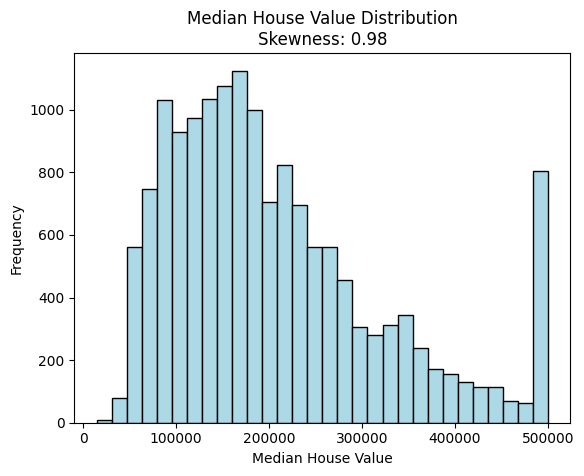

In [5]:
# Plot the distribution
plt.hist(1e5*y_train, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Distribution\nSkewness: {skew(y_train):.2f}')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

Right Skewed with a hard clip at 500K.

In [6]:
# Initialize and fit the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Predict on test set
y_pred_test = rf_regressor.predict(X_test)

In [7]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.3291
Mean Squared Error (MSE): 0.2542
Root Mean Squared Error (RMSE): 0.5042
R² Score: 0.8079


Mean Absolute Error is around 32k usd but Mean Squared Error or RMSE is around 50k usd. R2 score explains 80% of variance

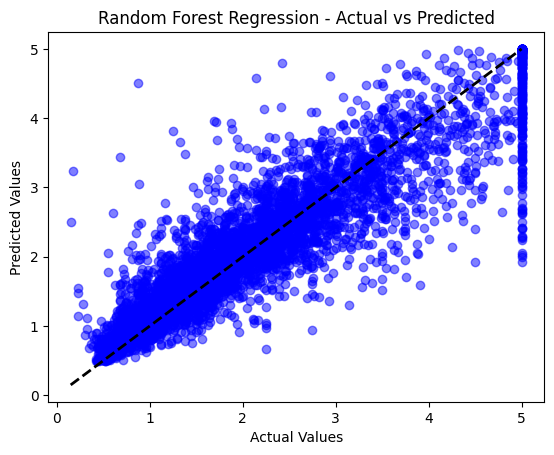

In [8]:
plt.scatter(y_test, y_pred_test, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression - Actual vs Predicted")
plt.show()

Points near diagonals are good predictions, but the clustering at 5 tells about the clip of 500k we saw above

Average error = -1605
Standard deviation of error = 50396


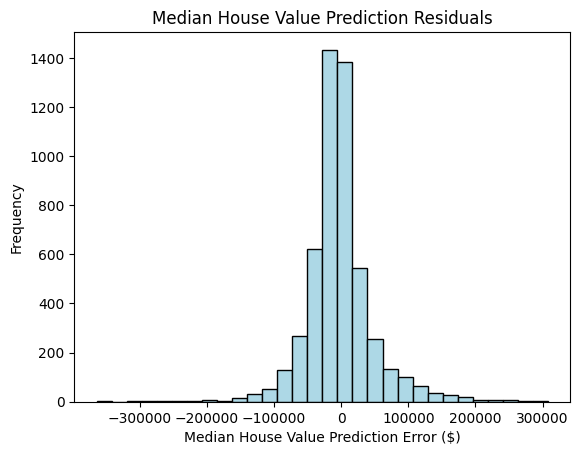

In [ ]:
residuals = 1e5*(y_test - y_pred_test)

# Plot the histogram of the residuals
plt.hist(residuals, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Prediction Residuals')
plt.xlabel('Median House Value Prediction Error ($)')
plt.ylabel('Frequency')

In [10]:
print('Average error = ' + str(int(np.mean(residuals))))
print('Standard deviation of error = ' + str(int(np.std(residuals))))

Average error = -1605
Standard deviation of error = 50396


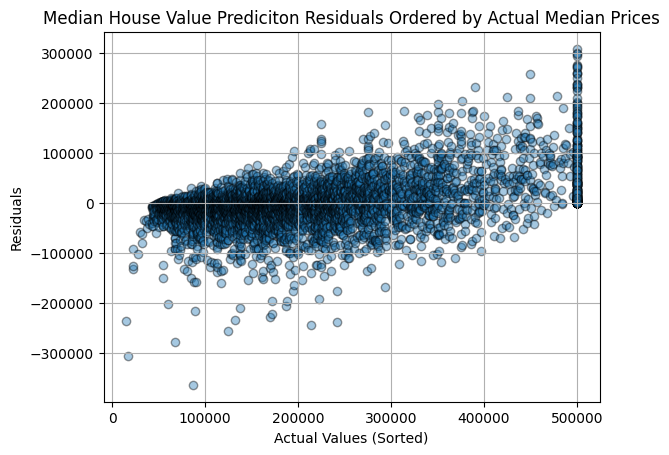

In [11]:
# Sort the DataFrame by the actual target values
residuals_df = pd.DataFrame({
    'Actual': 1e5*y_test,
    'Residuals': residuals
})
residuals_df = residuals_df.sort_values(by='Actual')

# Plot the residuals
plt.scatter(residuals_df['Actual'], residuals_df['Residuals'], marker='o', alpha=0.4,ec='k')
plt.title('Median House Value Prediciton Residuals Ordered by Actual Median Prices')
plt.xlabel('Actual Values (Sorted)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

Residuals sorted by actual value and plotted → reveals a trend: low-priced homes get over-predicted, high-priced homes get under-predicted. This is the classic "regression to the mean" pattern random forests show, worsened here by the price clipping.

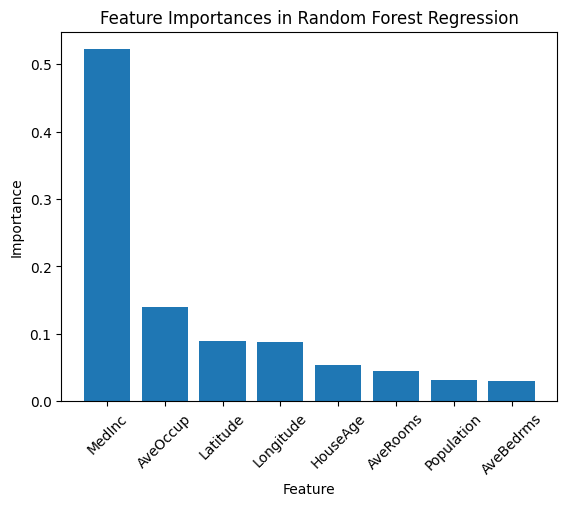

In [12]:
# Feature importances
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[::-1]
features = data.feature_names
# Plot feature importances
plt.bar(range(X.shape[1]), importances[indices],  align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")
plt.show()

Median income dominates. Latitude/longitude split importance roughly evenly, meaning location matters more than it visually appears (since it's split across two features instead of one combined "location" feature).

## Summary
- Clipping at $500k: biases predictions and can mislead metrics — worth removing those rows in preprocessing.
- Standardization: not needed for tree-based models (only matters for distance-based ones like KNN/SVM).